## Data pre-process:

##### Process Listing

1. Loading the Data
2. dealing with data in the wrong format 
3. dealing with missing values
4. Data Transformation
5. check the correlation between values
6. Save the data for post processing

### Loading the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import pickle

In [2]:
main_data = pd.read_csv(r"source_data/INDUSTRY_COPPER.csv")
main_data.head()

/var/folders/mx/9j_b405d4r94np4bc50lm07h0000gp/T/ipykernel_92243/2549818753.py:1: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  main_data = pd.read_csv(r"source_data/INDUSTRY_COPPER.csv")


,id,item_date,quantity tons,customer,country,status,item type,application,thickness,width,material_ref,product_ref,delivery date,selling_price
0,EC06F063-9DF0-440C-8764-0B0C05A4F6AE,20210401.0,54.151139,30156308.0,28.0,Won,W,10.0,2.00,1500.0,DEQ1 S460MC,1670798778,20210701.0,854.00
1,4E5F4B3D-DDDF-499D-AFDE-A3227EC49425,20210401.0,768.024839,30202938.0,25.0,Won,W,41.0,0.80,1210.0,0000000000000000000000000000000000104991,1668701718,20210401.0,1047.00
2,E140FF1B-2407-4C02-A0DD-780A093B1158,20210401.0,386.127949,30153963.0,30.0,Won,WI,28.0,0.38,952.0,S0380700,628377,20210101.0,644.33
3,F8D507A0-9C62-4EFE-831E-33E1DA53BB50,20210401.0,202.411065,30349574.0,32.0,Won,S,59.0,2.30,1317.0,DX51D+ZM310MAO 2.3X1317,1668701718,20210101.0,768.00
4,4E1C4E78-152B-430A-8094-ADD889C9D0AD,20210401.0,785.526262,30211560.0,28.0,Won,W,10.0,4.00,2000.0,2_S275JR+AR-CL1,640665,20210301.0,577.00


In [3]:
# check for how many original data in the pd.DataFrame
main_data.shape

(181673, 14)

## dealing with data in the wrong format 

In [4]:
# handling data and time
main_data['item_date'] = pd.to_datetime(main_data['item_date'], format='%Y%m%d', errors='coerce').dt.date

In [5]:
# handling the categorical variable
main_data['quantity tons'] = pd.to_numeric(main_data['quantity tons'], errors='coerce')
main_data['customer'] = pd.to_numeric(main_data['customer'], errors='coerce')
main_data['country'] = pd.to_numeric(main_data['country'], errors='coerce')
main_data['application'] = pd.to_numeric(main_data['application'], errors='coerce')
main_data['thickness'] = pd.to_numeric(main_data['thickness'], errors='coerce')
main_data['width'] = pd.to_numeric(main_data['width'], errors='coerce')
main_data['material_ref'] = main_data['material_ref'].str.lstrip('0')
main_data['product_ref'] = pd.to_numeric(main_data['product_ref'], errors='coerce')
main_data['delivery date'] = pd.to_datetime(main_data['delivery date'], format='%Y%m%d', errors='coerce').dt.date
main_data['selling_price'] = pd.to_numeric(main_data['selling_price'], errors='coerce')

## dealing with missing values

In [6]:
# check for number of missing values
main_data.isnull().sum()

id                   2
item_date            3
quantity tons        1
customer             1
country             28
status               2
item type            0
application         24
thickness            1
width                0
material_ref     77919
product_ref          0
delivery date        3
selling_price        1
dtype: int64

In [7]:
# material_ref - 77919 is 42.89% of the whole data. can't be droped instead replaceing it with 'None'  
main_data['material_ref'].fillna('none', inplace=True)

/var/folders/mx/9j_b405d4r94np4bc50lm07h0000gp/T/ipykernel_92243/383748141.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  main_data['material_ref'].fillna('none', inplace=True)


In [8]:
# remove all the Null values in this DataFrame
main_data.dropna(inplace=True)

In [9]:
# Check again for the missing values.
main_data.isnull().sum()

id               0
item_date        0
quantity tons    0
customer         0
country          0
status           0
item type        0
application      0
thickness        0
width            0
material_ref     0
product_ref      0
delivery date    0
selling_price    0
dtype: int64

## Data Transformation

In [10]:
plot_data = main_data.copy()

In [11]:
# plot the data in an distplot for identifing skewed data

import warnings
warnings.filterwarnings("ignore")

/var/folders/mx/9j_b405d4r94np4bc50lm07h0000gp/T/ipykernel_92243/2804773825.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(plot_data['quantity tons'], ax=axes[0])
/var/folders/mx/9j_b405d4r94np4bc50lm07h0000gp/T/ipykernel_92243/2804773825.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(

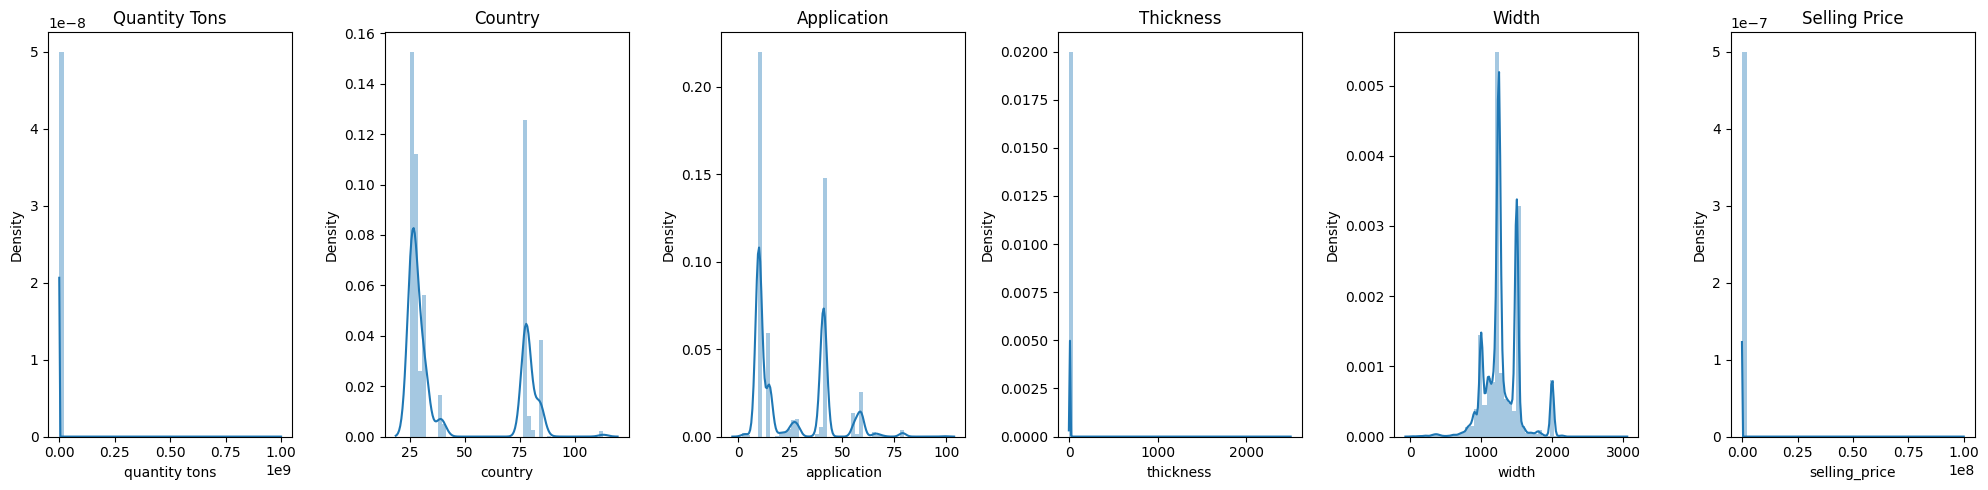

In [12]:
# Create a figure with 1 row and 6 columns
fig, axes = plt.subplots(1, 6, figsize=(20, 5))

# Plot each distribution in a separate subplot
sns.distplot(plot_data['quantity tons'], ax=axes[0])
axes[0].set_title('Quantity Tons')

sns.distplot(plot_data['country'], ax=axes[1])
axes[1].set_title('Country')

sns.distplot(plot_data['application'], ax=axes[2])
axes[2].set_title('Application')

sns.distplot(plot_data['thickness'], ax=axes[3])
axes[3].set_title('Thickness')

sns.distplot(plot_data['width'], ax=axes[4])
axes[4].set_title('Width')

sns.distplot(plot_data['selling_price'], ax=axes[5])
axes[5].set_title('Selling Price')

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

In [13]:
# "Quantity_tons", "thickness" and "selling price" all three is skewed

In [14]:
# Normalize all three of the data by replacing with nan

mask1 = plot_data['selling_price'] <= 0
print(f"selling_price => {mask1.sum()}")
plot_data.loc[mask1, 'selling_price'] = np.nan

mask1 = plot_data['quantity tons'] <= 0
print(f"quantity tons => {mask1.sum()}")
plot_data.loc[mask1, 'quantity tons'] = np.nan

mask1 = plot_data['thickness'] <= 0
print(f"thickness => {mask1.sum()}")
plot_data.loc[mask1, 'thickness'] = np.nan

selling_price => 7
quantity tons => 4
thickness => 0


In [15]:
plot_data.isnull().sum()

id               0
item_date        0
quantity tons    4
customer         0
country          0
status           0
item type        0
application      0
thickness        0
width            0
material_ref     0
product_ref      0
delivery date    0
selling_price    7
dtype: int64

In [16]:
plot_data.dropna(inplace=True)
plot_data.isnull().sum()

id               0
item_date        0
quantity tons    0
customer         0
country          0
status           0
item type        0
application      0
thickness        0
width            0
material_ref     0
product_ref      0
delivery date    0
selling_price    0
dtype: int64

#### log transformation

/var/folders/mx/9j_b405d4r94np4bc50lm07h0000gp/T/ipykernel_92243/3353200406.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(plot_data['selling_price_log'], ax=axes[0])
/var/folders/mx/9j_b405d4r94np4bc50lm07h0000gp/T/ipykernel_92243/3353200406.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.dist

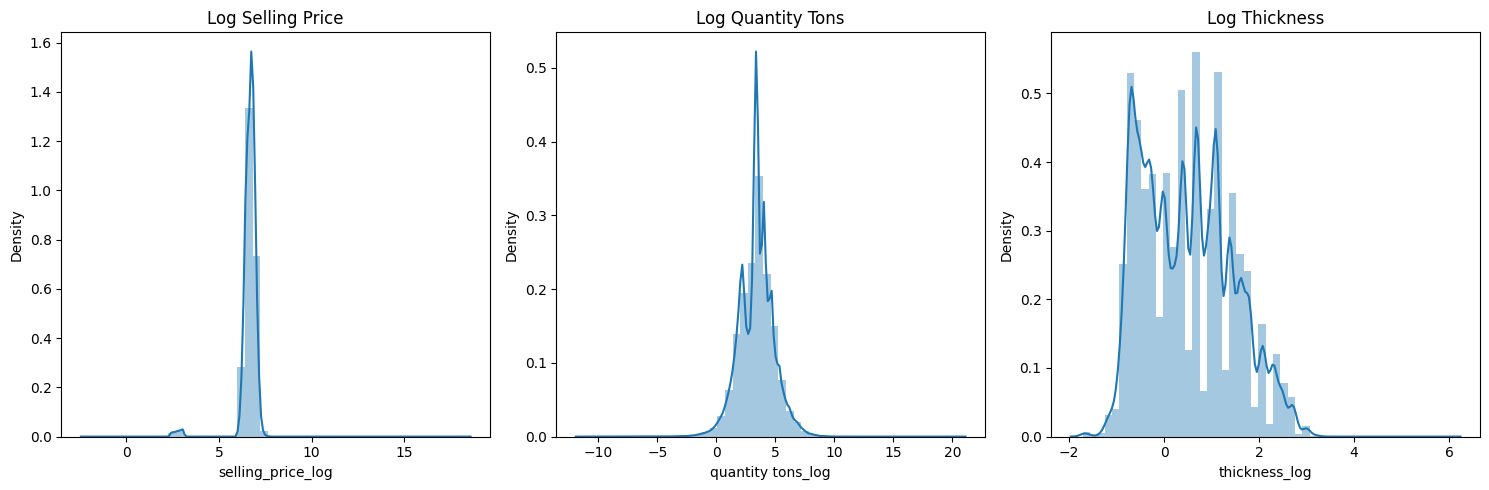

In [17]:
plot_data['selling_price_log'] = np.log(plot_data['selling_price'])
plot_data['quantity tons_log'] = np.log(plot_data['quantity tons'])
plot_data['thickness_log'] = np.log(plot_data['thickness'])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.distplot(plot_data['selling_price_log'], ax=axes[0])
axes[0].set_title('Log Selling Price')

sns.distplot(plot_data['quantity tons_log'], ax=axes[1])
axes[1].set_title('Log Quantity Tons')

sns.distplot(plot_data['thickness_log'], ax=axes[2])
axes[2].set_title('Log Thickness')

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

## check the correlation between values in the data

In [18]:
x=plot_data[['quantity tons_log','application','thickness_log',
             'width','selling_price_log','country','customer','product_ref']].corr()

<Axes: >

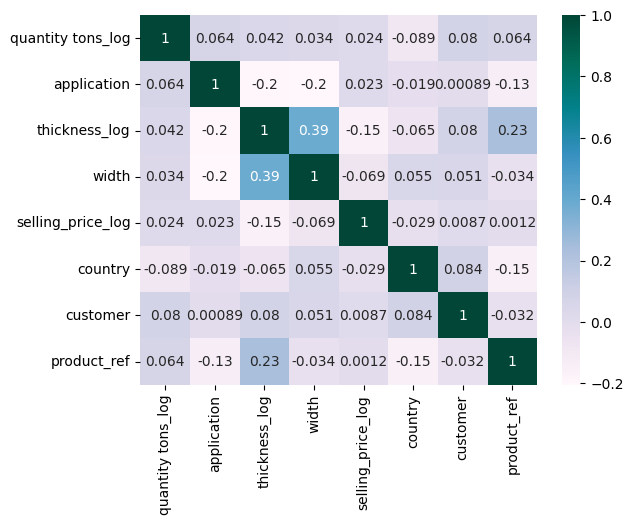

In [19]:
sns.heatmap(x, annot=True, cmap="PuBuGn")

## Load the data to a file

In [20]:
# for training and other  works

plot_data.to_csv('source_data/preprocessed_data.csv', index=False)

# Predictiong the price 

Predicting the price is a regression task.
here Decision tree regressor for fast and interpretable result. Beacuse, it uses single tree from root to leaf. 
Random forest regressor for better accuracy and stability. It takes multiple tree, so it takes much compute power.
Much compute power is not avialable here.

#### Decision tree regressor (Price_prediction)

In [21]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.metrics import mean_squared_error, accuracy_score, r2_score

In [22]:
piped_data = plot_data.copy()

In [23]:
# piped_data.reset_index(drop=True)
piped_data.head(2)

,id,item_date,quantity tons,customer,country,status,item type,application,thickness,width,material_ref,product_ref,delivery date,selling_price,selling_price_log,quantity tons_log,thickness_log
0,EC06F063-9DF0-440C-8764-0B0C05A4F6AE,2021-04-01,54.151139,30156308.0,28.0,Won,W,10.0,2.0,1500.0,DEQ1 S460MC,1670798778,2021-07-01,854.0,6.749931,3.991779,0.693147
1,4E5F4B3D-DDDF-499D-AFDE-A3227EC49425,2021-04-01,768.024839,30202938.0,25.0,Won,W,41.0,0.8,1210.0,104991,1668701718,2021-04-01,1047.0,6.953684,6.643822,-0.223144


In [24]:
# seperate the data from the outcome
# 'id','customer', 'item_date','delivery date' are not the type of data that should affect outcome
# Item type and status are the only encodable options options, an 
x = piped_data[['quantity tons_log','application','thickness_log','width','country','customer','product_ref',
                'status','item type']]
y = piped_data['selling_price_log']

#### encoding columns
```plaintext
  unique value columns
    - item type       7 
    - status         9
    - product_ref    33
    - application    30
    - country        17

product_ref, application, country are already numerical values, encoding for it is not needed.
item_type and status are Categorical with low cardinality, so going for OneHotEncoding.
```

In [25]:
x.head()

,quantity tons_log,application,thickness_log,width,country,customer,product_ref,status,item type
0,3.991779,10.0,0.693147,1500.0,28.0,30156308.0,1670798778,Won,W
1,6.643822,41.0,-0.223144,1210.0,25.0,30202938.0,1668701718,Won,W
2,5.956169,28.0,-0.967584,952.0,30.0,30153963.0,628377,Won,WI
3,5.310301,59.0,0.832909,1317.0,32.0,30349574.0,1668701718,Won,S
4,6.666354,10.0,1.386294,2000.0,28.0,30211560.0,640665,Won,W


In [26]:
print(x.shape,y.shape)

(181620, 9) (181620,)


In [27]:
#### 'Item type' and 'status' are falling into few catogries, 'material_ref' is not includeded in df
#### 'Item type' has 'won' and 'lost', 'Not lost for AM','To be approved'

ohe_1 = OneHotEncoder(handle_unknown='ignore')
ohe_1.fit(x[['status']])
paired_1 = ohe_1.transform(x[['status']]).toarray()

In [28]:
ohe_2 = OneHotEncoder(handle_unknown='ignore')
ohe_2.fit(x[['item type']])
paired_2 = ohe_2.transform(x[['item type']]).toarray()

In [29]:
# combining features x_ohe has 'item type' and 'status' encoded.  add other with it.
x_combined = np.hstack((x[['quantity tons_log','application','thickness_log','width','country',
                           'customer','product_ref']].values, paired_1, paired_2))

In [30]:
# Scale the combined features
scaler = StandardScaler()
x = scaler.fit_transform(x_combined)

In [31]:
# Split the data into training and testing data sets
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=42)

In [32]:
# Train a DecisionTreeRegressor to predict selling_price
DTR = DecisionTreeRegressor(random_state=42)

### hyperparameters
Hyperparam_grid = {
    'max_depth': [3, 5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2'],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']
}

In [33]:
# hyperparameters
Hyperparam_grid = {
    'max_depth': [3, 5, 10, 20,50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2'] # ,'criterion': ['squared_error', 'absolute_error', 'friedman_mse']
}

In [34]:
# Run next two cells contionuesly.
start_time = time.time() # Start timer

In [35]:
# GridSearchCV

grid_search = GridSearchCV(DTR, Hyperparam_grid, cv=5, scoring='r2',n_jobs=-1)
grid_search.fit(X_train, y_train)


/Users/guest1/PycharmProjects/Industrial-Copper-Modeling/.venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
225 fits failed out of a total of 675.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
133 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/guest1/PycharmProjects/Industrial-Copper-Modeling/.venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/guest1/PycharmProjects/Industrial-Copper-Modeling/.venv/lib/python3.13/site-packages/sklearn/base.py", line 1382, in wrapper
    estimator._vali

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [3, 5, 10, 20, 50],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='r2')

In [36]:

end_time = time.time() # End timer

# Calculate elapsed time
elapsed_time = end_time - start_time
print(f"GridSearchCV took {elapsed_time:.2f} seconds")

GridSearchCV took 10.46 seconds


In [37]:
# Best Model
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

In [38]:
# Evaluation
mse = mean_squared_error(y_test, y_pred)  # Mean Absolute Error
r2 = r2_score(y_test, y_pred)   # R2 score
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100  # Mean Absolute Percentage Error

In [39]:
print("Best hyperparameters:", grid_search.best_params_)

Best hyperparameters: {'max_depth': 50, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10}


In [40]:
print('Mean Squared Error:', mse)
print('R-Squared:', r2)
print('Mean Absolute Percentage Error:', mape, "%")

Mean Squared Error: 0.026617606293260855
R-Squared: 0.9173805058454183
Mean Absolute Percentage Error: 1.957155129354772 %


Mean Squared Error: 0.028348808411033363
R-Squared: 0.9120069556593552
Mean Absolute Percentage Error: 2.017347296074443 %

In [41]:
def price_predicter(quantity_log, application, thickness_log, width, country, customer, product_ref, item_type, status):
    # ['quantity tons_log', 'application', 'thickness_log', 'width','country','customer','product_ref']].values, X_ohe, X_be
    new_sample = np.array([[np.log(quantity_log), application, np.log(thickness_log), width, country,
                            customer,product_ref, item_type, status]])
    new_sample_ohe1 = ohe_1.transform(new_sample[:, [7]]).toarray()
    new_sample_ohe2 = ohe_2.transform(new_sample[:, [8]]).toarray()
    new_sample_stack = np.hstack((new_sample[:, [0,1,2,3,4,5,6]], new_sample_ohe1, new_sample_ohe2))
    new_sample1 = scaler.transform(new_sample_stack)
    new_pred = best_model.predict(new_sample1)
    print('Predicted selling price:', np.exp(new_pred))

In [42]:
# previous pred - 554.14247792
# act ans - 854
price_predicter(quantity_log = 54.151139, application = 10, 
                 thickness_log= 2, width = '1500', country = 28, customer = 30156308, 
                 product_ref = '1670798778', item_type = 'W', status = 'Won')

Predicted selling price: [754.61247343]


/Users/guest1/PycharmProjects/Industrial-Copper-Modeling/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(
/Users/guest1/PycharmProjects/Industrial-Copper-Modeling/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


In [43]:
# act ans - 1047
price_predicter(quantity_log = 768.024839, application = 41, 
                 thickness_log= 0.80, width = '1210', country = 25, customer = 30202938, 
                 product_ref = '1668701718', item_type = 'W', status = 'Won')

Predicted selling price: [1024.324067]


/Users/guest1/PycharmProjects/Industrial-Copper-Modeling/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(
/Users/guest1/PycharmProjects/Industrial-Copper-Modeling/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


In [44]:
# act ans - 1047
price_predicter(quantity_log = 386.127949, application = 28, 
                 thickness_log= 0.38, width = '952', country = 30, customer = 30153963, 
                 product_ref = '628377', item_type = 'WI', status = 'Won')

Predicted selling price: [803.03501244]


/Users/guest1/PycharmProjects/Industrial-Copper-Modeling/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(
/Users/guest1/PycharmProjects/Industrial-Copper-Modeling/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


#### Saving the model

In [45]:
def save_it(artifact, filename):
    filepath = f"model_data/{filename}.pkl"
    with open(filepath, 'wb') as file:
        pickle.dump(artifact, file)
    print(f"saved {filename}.pkl")

In [46]:
save_it(best_model,'regression_model')

saved regression_model.pkl


## DECISION TREE CLASSIFIER

Here we need to predict Won or Lost in only. No need add other in DataFrame.

In [47]:
clsdf = piped_data[piped_data['status'].isin(['Won', 'Lost'])]

In [48]:
# how much missing in won/lost drop
len(piped_data) - len(clsdf)

31193

In [49]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler, OneHotEncoder,LabelBinarizer
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

In [50]:
X = clsdf[['quantity tons_log','selling_price_log','item type','application','thickness_log',
         'width','country','customer','product_ref']]
Y = clsdf['status']

In [51]:
# Don't previously encoded 'item type' it containes other than won/loss data which is not ordered to 'clsdf' here.
# encoding categorical variables
ohe = OneHotEncoder(handle_unknown='ignore')
ohe.fit(X[['item type']])
X_ohe = ohe.fit_transform(X[['item type']]).toarray()

In [52]:
be = LabelBinarizer()
be.fit(Y) 
y = be.fit_transform(Y)

In [53]:
# independent features after encoding
X = np.hstack((X[['quantity tons_log', 'selling_price_log','application', 
                       'thickness_log', 'width','country','customer','product_ref']].values, X_ohe))


In [54]:
scaler = StandardScaler()
X = scaler.fit_transform(X)


In [55]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [56]:
# decision tree classifier
dtc = DecisionTreeClassifier()
dtc.fit(X_train, y_train)
y_pred = dtc.predict(X_test)


In [57]:

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
cm = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix:\n{cm}")

Accuracy: 0.9132154490460679
Confusion Matrix:
[[ 5694  1308]
 [ 1303 21781]]


Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.81      0.81      7002
           1       0.94      0.94      0.94     23084

    accuracy                           0.91     30086
   macro avg       0.88      0.88      0.88     30086
weighted avg       0.91      0.91      0.91     30086



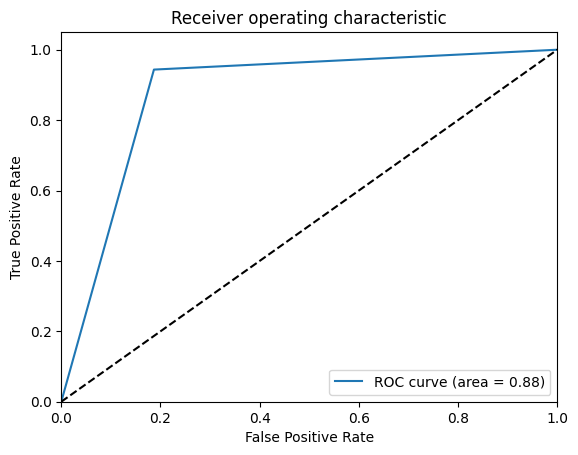

In [58]:
# Evalution Metrics
print("Classification Report:")
print(classification_report(y_test, y_pred))
# ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.show()


In [59]:
# Predict the status for a new sample
# 'quantity tons_log','selling_price_log','application','thickness_log','width','country','customer','product_ref','item type'

def status_classification(quantity, sale_price, application, thickness, width, country, customer, product_ref, item_type):
    new_sample = np.array([[np.log(quantity), np.log(sale_price), application, np.log(thickness),
                            width,country,customer,product_ref,item_type]])
    new_sample_ohe = ohe.transform(new_sample[:, [8]]).toarray()
    new_sample = np.hstack((new_sample[:, [0,1,2, 3, 4, 5, 6,7]], new_sample_ohe))
    new_sample = scaler.transform(new_sample)
    new_pred = dtc.predict(new_sample)
    if new_pred==1:
        print('The status is: Won')
    else:
        print('The status is: Lost')

In [60]:
status_classification(quantity=700, sale_price=956, application=10, thickness=1500, width=28.0, country=28, 
                      customer=30202938, product_ref=1670798778,item_type='W')

The status is: Won


/Users/guest1/PycharmProjects/Industrial-Copper-Modeling/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


#### Saving the model

In [61]:
save_it(dtc,'classifier_model')

saved classifier_model.pkl
